<a href="https://colab.research.google.com/github/MahuL88/Latihan/blob/main/BankJago_Test_Intern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load Dataset

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 13.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
import optuna
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold

# For Parametrik
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# For Non-parametrik
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

In [3]:
# Load data ke sebuah dataframe bernama Card Usage(CU)
cu = pd.read_csv('/content/card_usage.csv')

In [4]:
# Melihat jumlah kolom dan baris
cu.shape

(284807, 31)

In [5]:
cu.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Analisis Dasar Statistik
cu.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
# Cek duplikat
cu.duplicated().sum()

np.int64(1081)

In [8]:
cu[cu.duplicated(keep=False)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284190,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0
284192,172233.0,-2.691642,3.123168,-3.339407,1.017018,-0.293095,-0.167054,-0.745886,2.325616,-1.634651,...,0.402639,0.259746,-0.086606,-0.097597,0.083693,-0.453584,-1.205466,-0.213020,36.74,0


In [9]:
# hapus duplikat
cu_new = cu.drop_duplicates()

In [10]:
# Melihat jumlah kolom dan baris
cu_new.shape

(283726, 31)

# Analisis Data

In [11]:
# Tidak ada missing Value dan type datanya sudah sesuai
cu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
# V28 distribusinya sangat condong/miring ke kanan (skewed positif) dan V8 miring ke kiri (skewed negatif)
for col in [f"V{i}" for i in range(1,29)]:
    print(col, "skewness =", skew(cu_new[col]))

V1 skewness = -3.2732539433146486
V2 skewness = -4.695137078165384
V3 skewness = -2.1519725799940685
V4 skewness = 0.6715006205655543
V5 skewness = -2.414066484215612
V6 skewness = 1.829870709562578
V7 skewness = 2.8902559124339735
V8 skewness = -8.310926391626731
V9 skewness = 0.5376602109334492
V10 skewness = 1.2529604545622932
V11 skewness = 0.34407237420591985
V12 skewness = -2.198996655901221
V13 skewness = 0.06429306473390328
V14 skewness = -1.9187935694299705
V15 skewness = -0.3096574451884751
V16 skewness = -1.0511559142385323
V17 skewness = -3.690477683233225
V18 skewness = -0.24866014274940992
V19 skewness = 0.1083112383097532
V20 skewness = -2.043110254457915
V21 skewness = 2.8200182046255926
V22 skewness = -0.18232876403467282
V23 skewness = -5.867189772192024
V24 skewness = -0.5521263176758532
V25 skewness = -0.41574166410065255
V26 skewness = 0.5802892493462333
V27 skewness = -0.7537999286092231
V28 skewness = 11.555053994631207


In [13]:
# nilai class imbalance
print(cu_new['Class'].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


#Performing statistical calculations

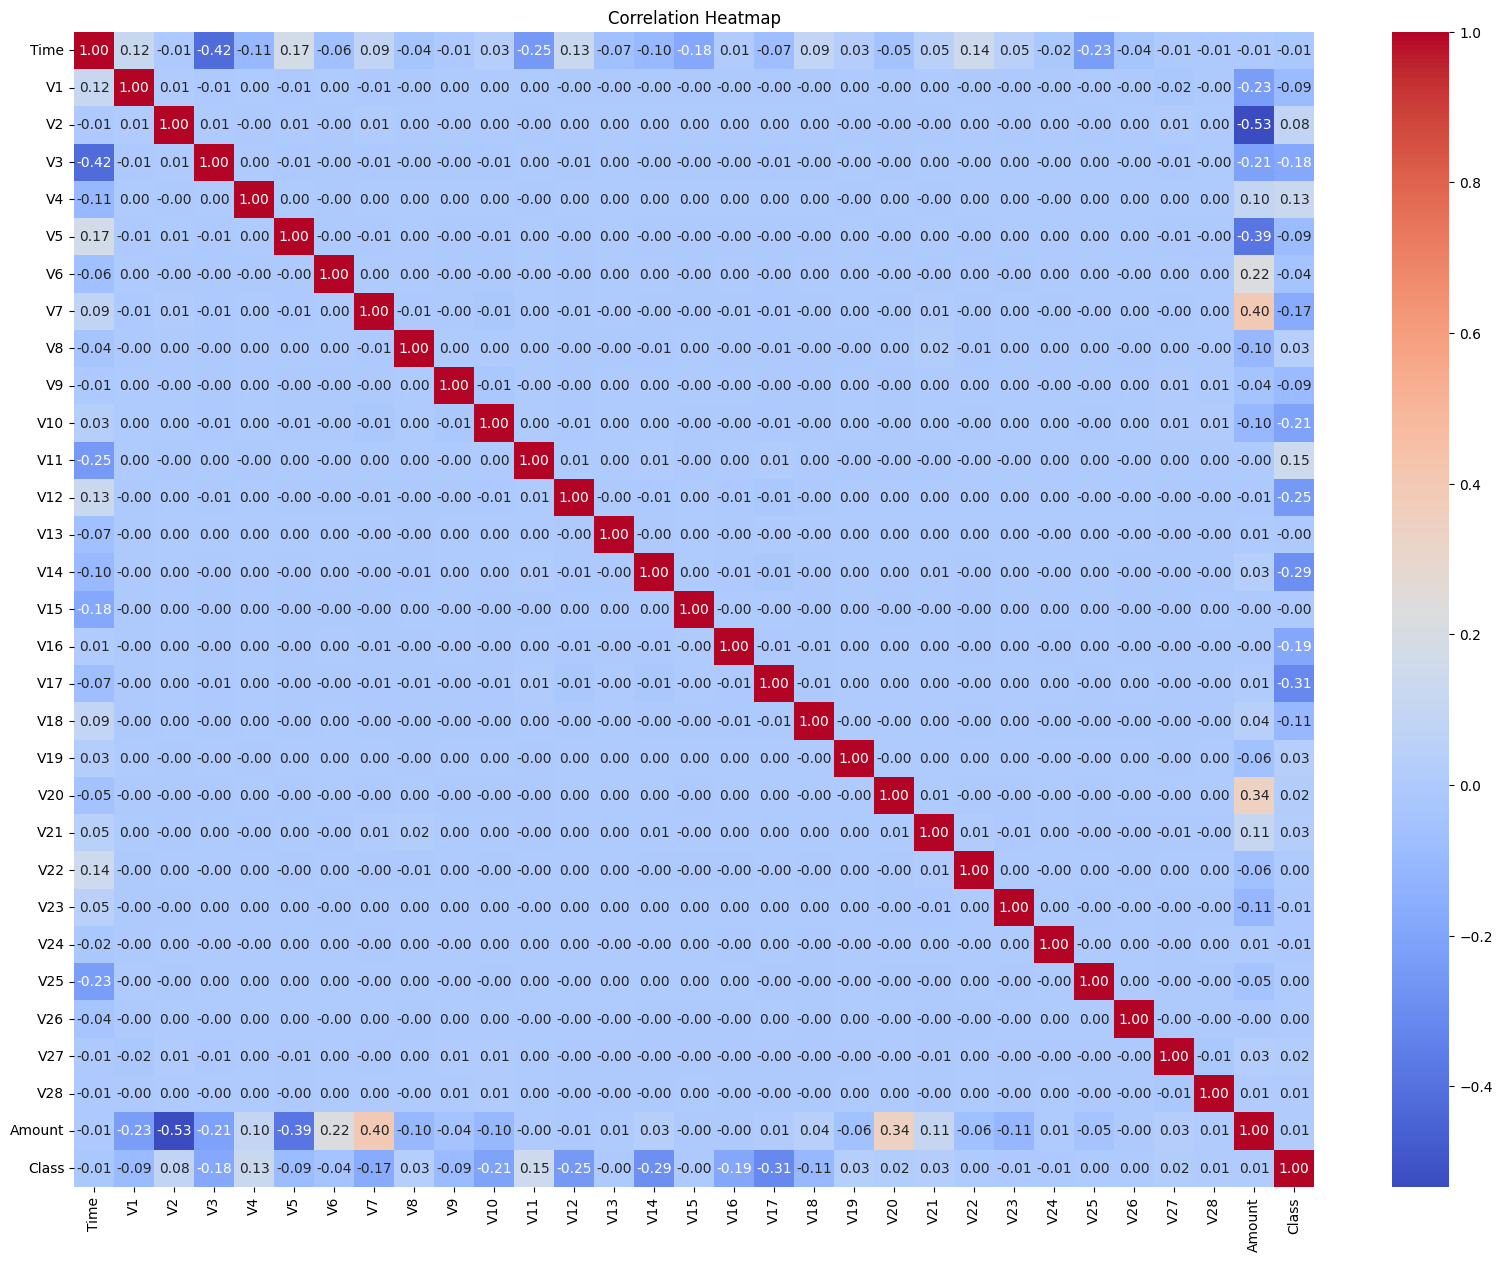

In [14]:
corr = cu_new.corr()   # Menggunakan Pearson correlation

plt.figure(figsize=(20,15))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Dari gambar, terlihat bahwa kebanyakan fitur berkorelasi negatif dengan class seperti fitur V3,V7,V10,V12,V14,V16,dan V17 serta berkolerasi positif pada V4 dan V11.

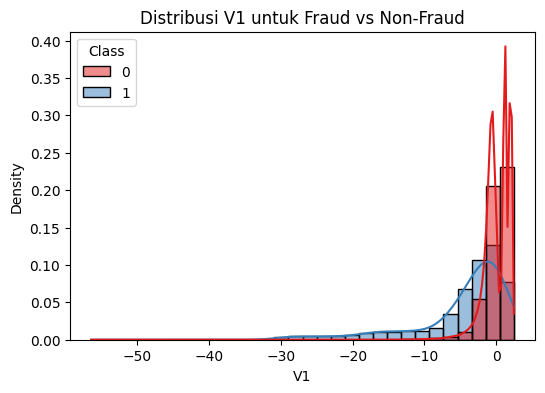

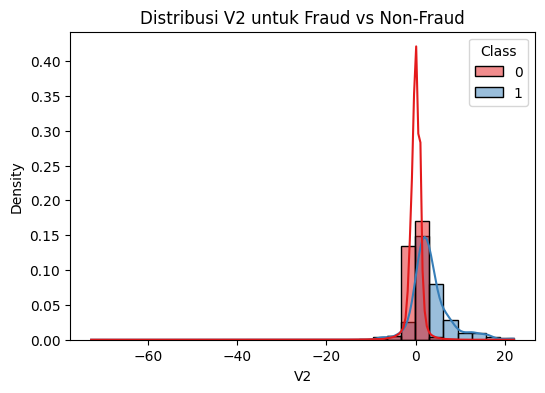

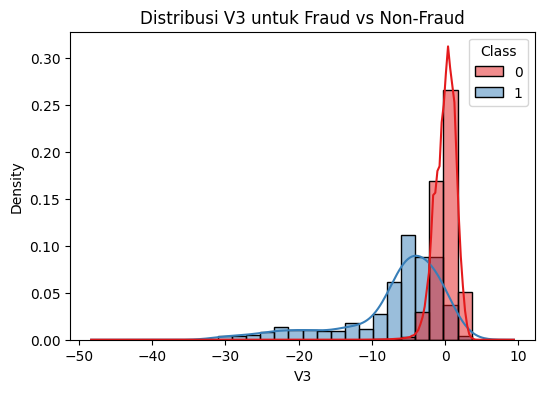

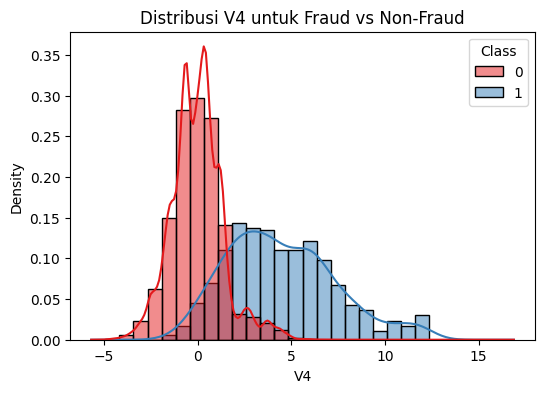

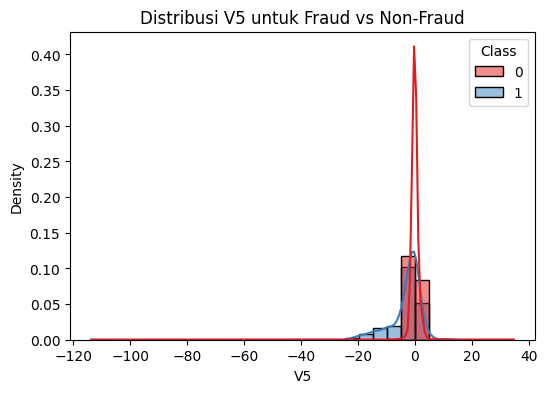

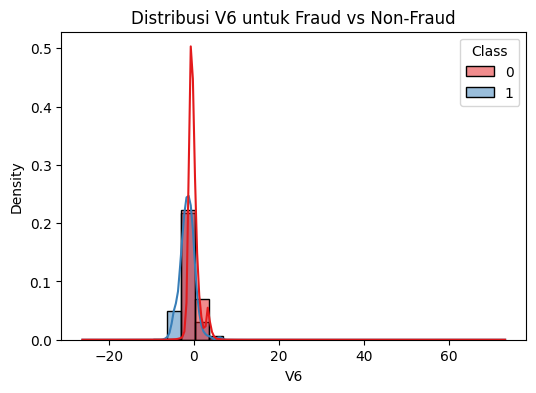

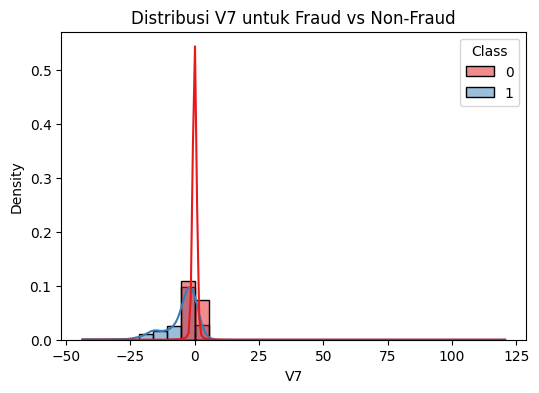

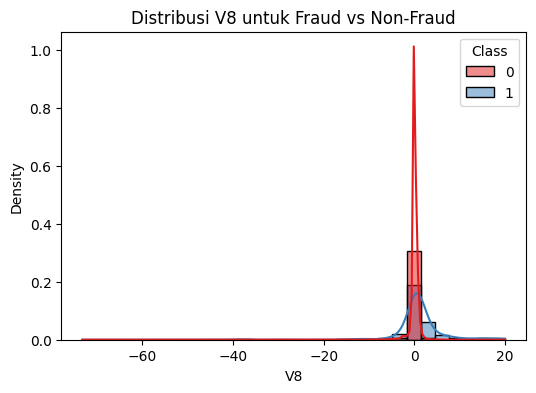

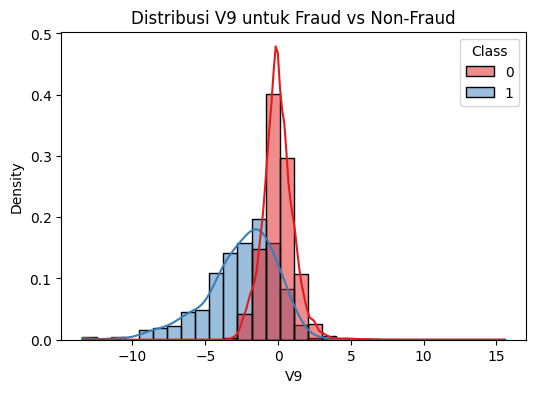

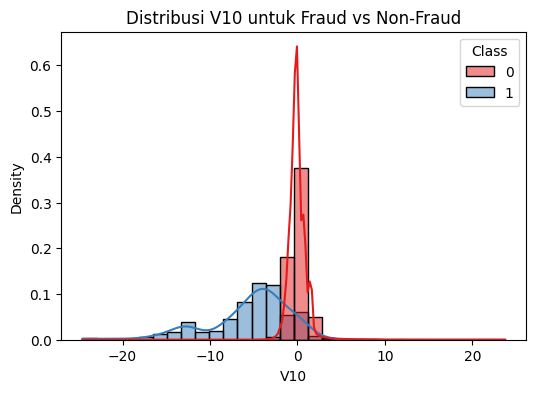

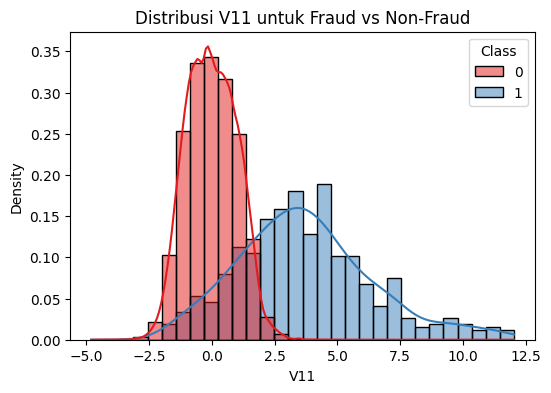

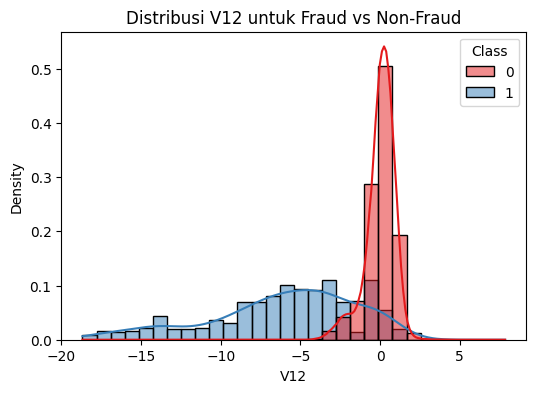

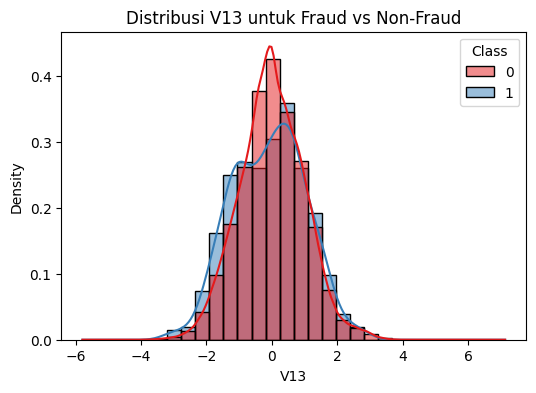

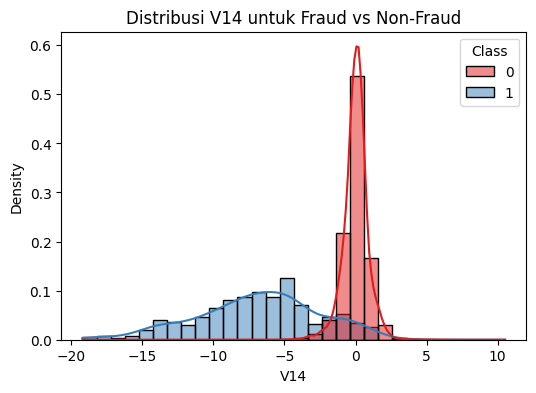

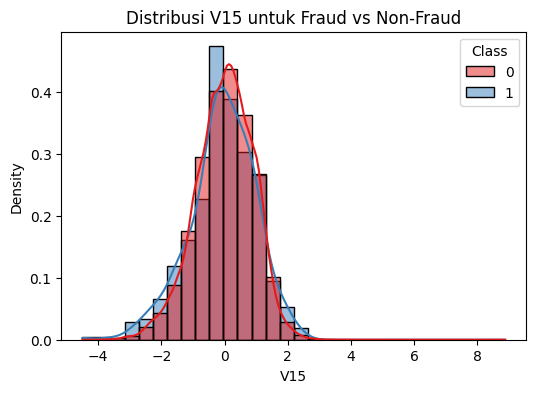

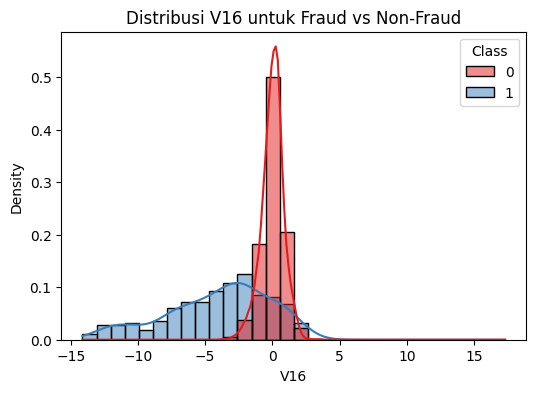

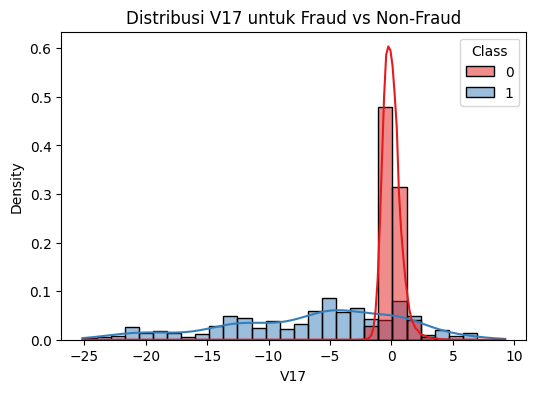

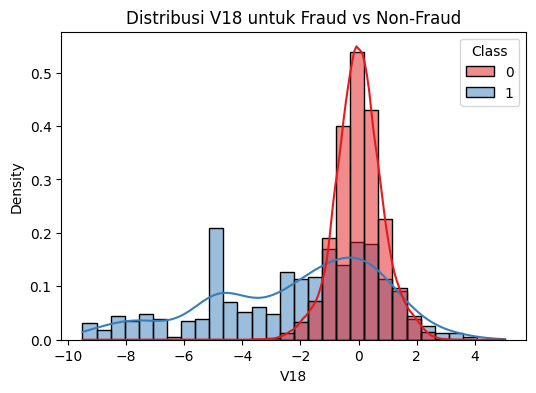

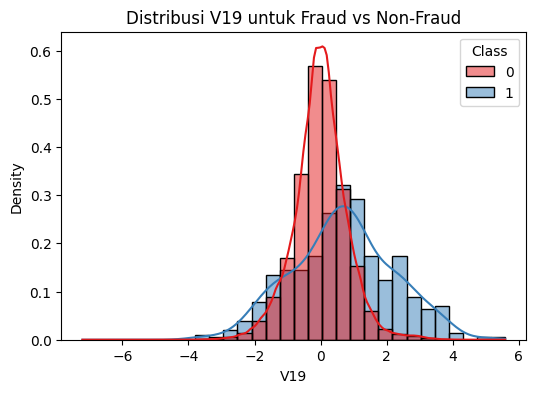

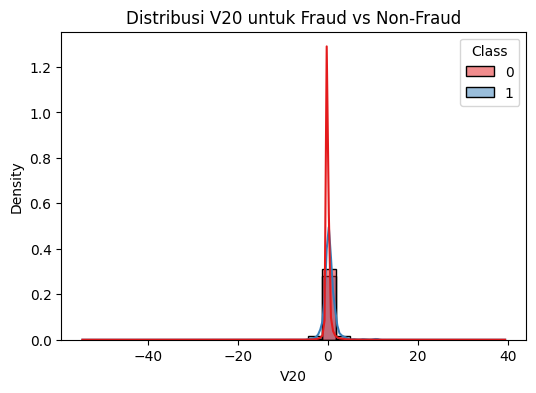

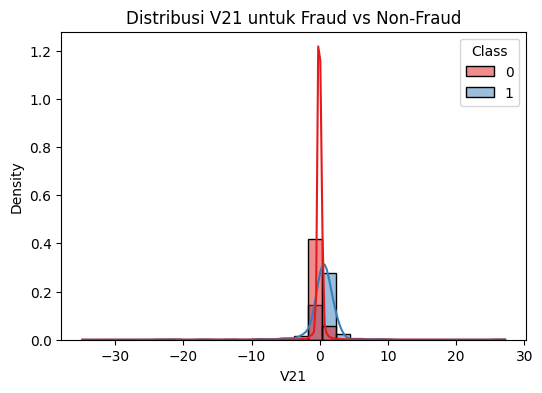

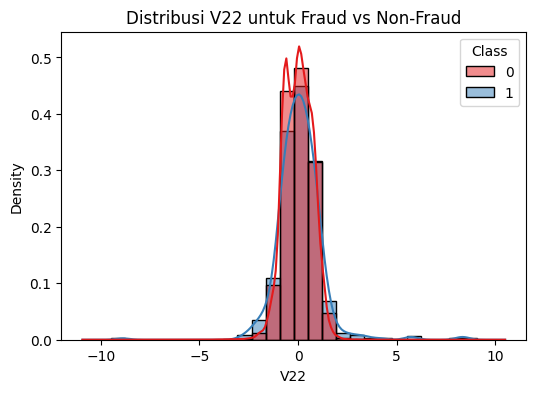

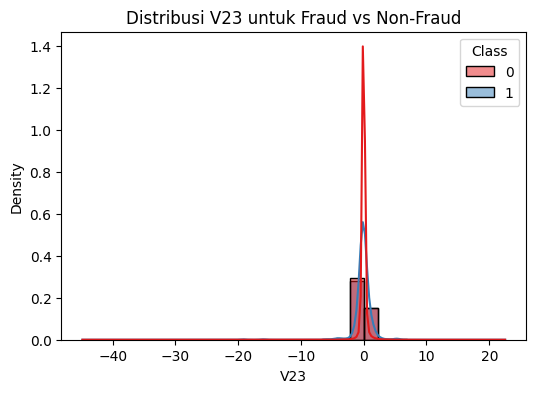

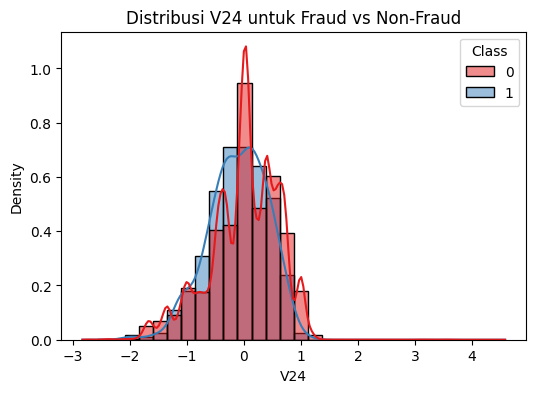

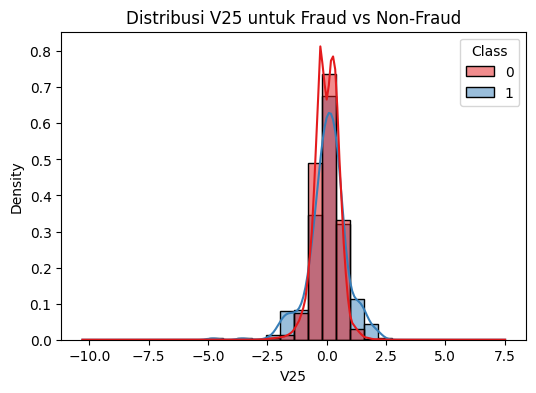

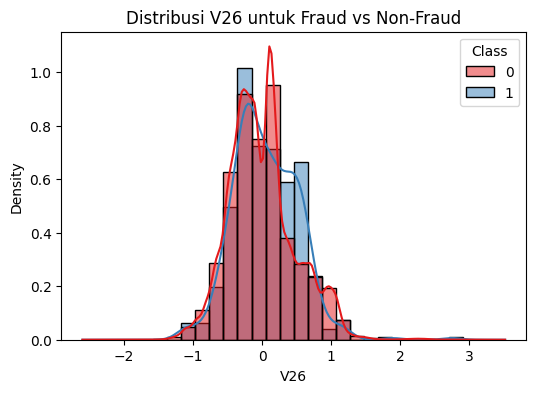

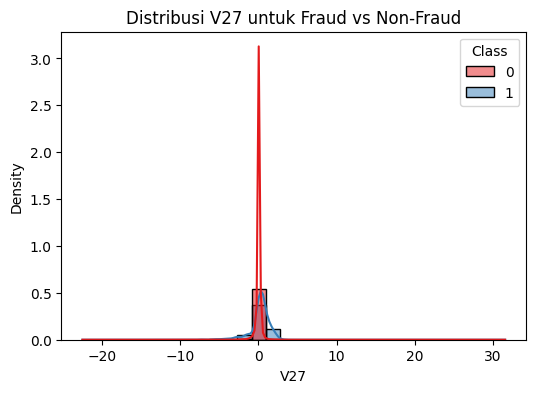

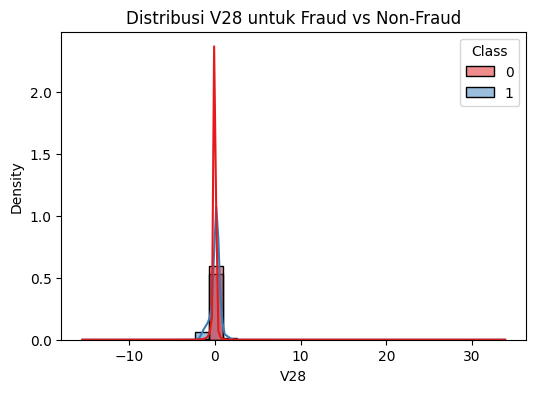

In [15]:
# Cek distribusi tiap fitur
features = [f"V{i}" for i in range(1,29)]  # V1–V21

for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=cu_new, x=col, hue="Class", kde=True, bins=30, palette="Set1", common_norm=False, stat="density")
    plt.title(f"Distribusi {col} untuk Fraud vs Non-Fraud")
    plt.show()

Dari histogram tersebut, terlihat bahwa distribusi antara class 0 dan 1 yang berbeda pada fitur V3,V4,V9,V10,V11,V12,V14,V16,V18,dan V19 agar dengan mudah membedakan antara fraud dan non-fraud pada fitur tersebut.

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


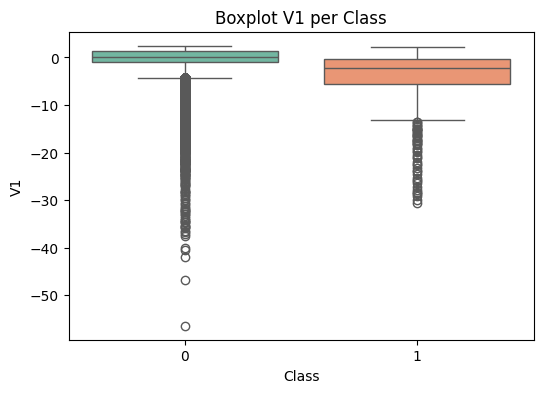

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


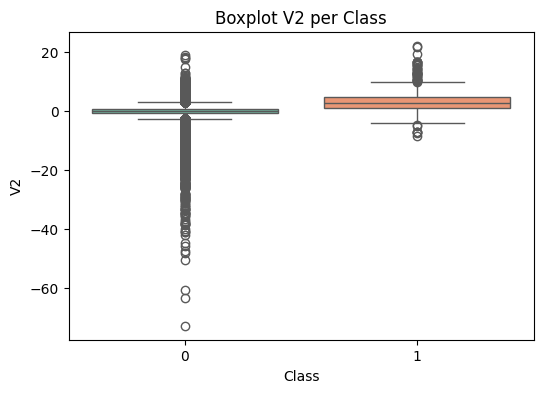

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


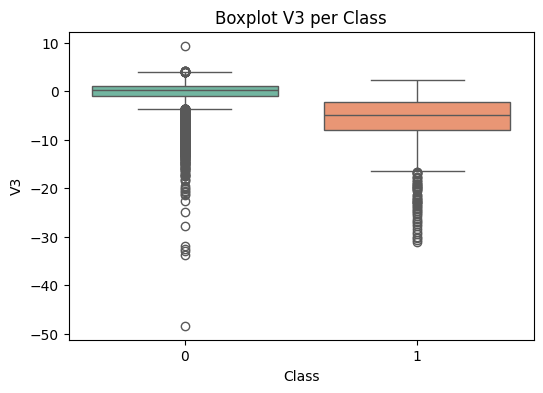

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


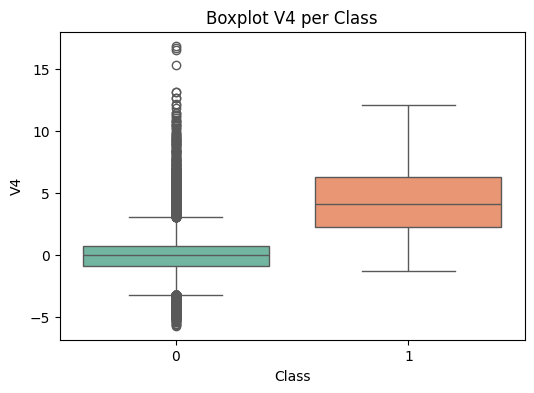

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


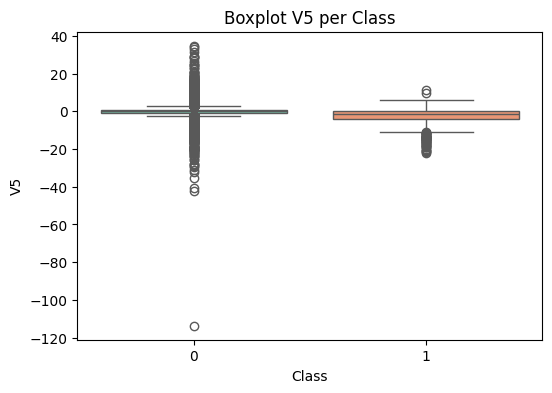

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


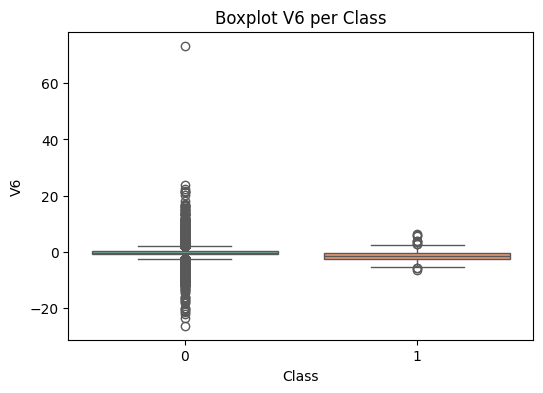

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


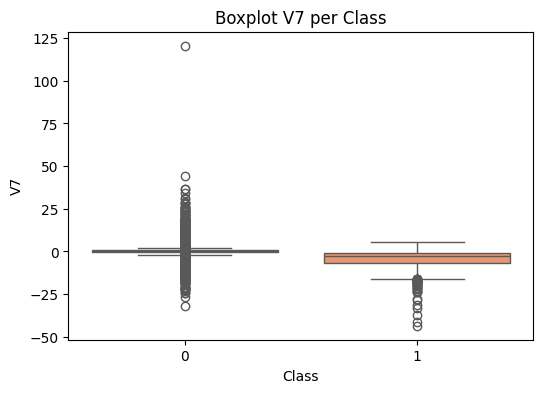

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


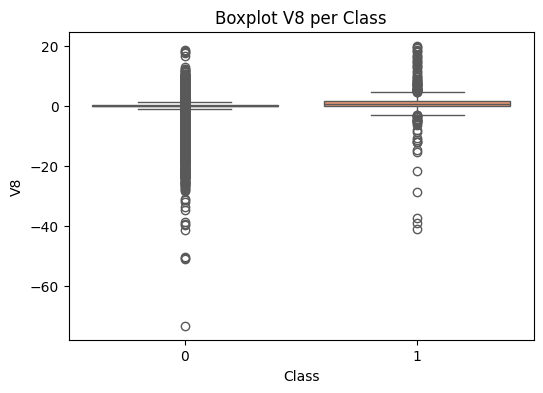

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


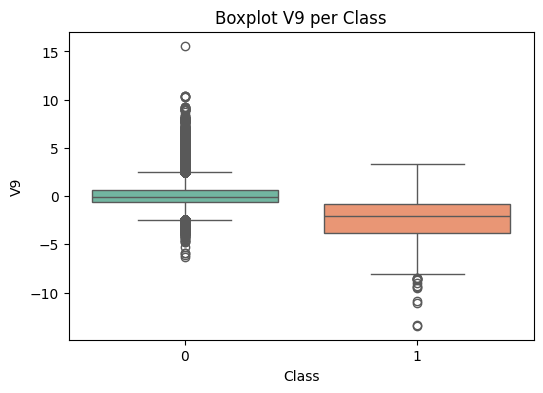

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


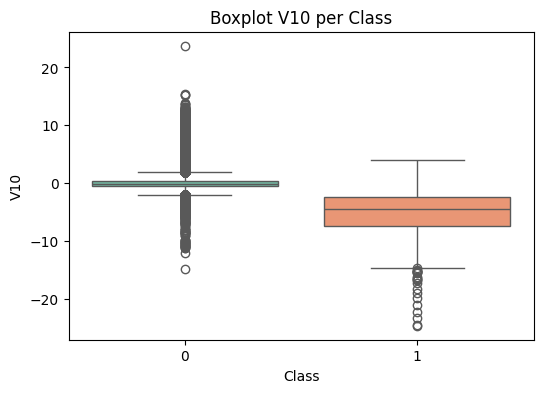

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


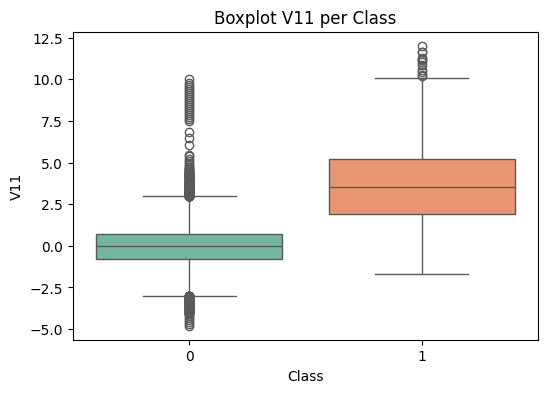

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


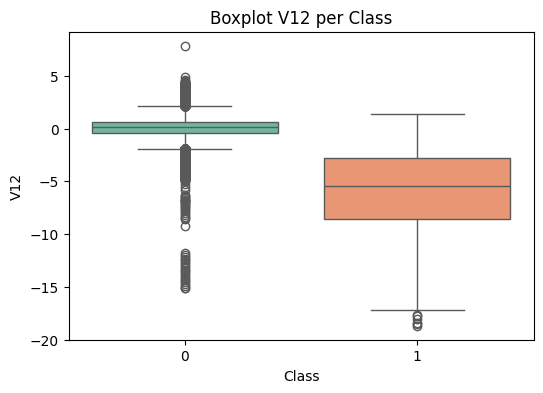

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


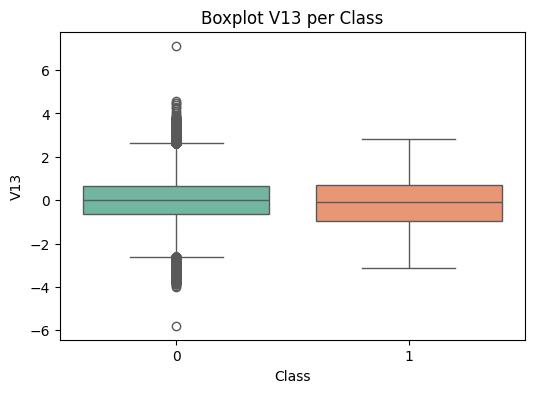

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


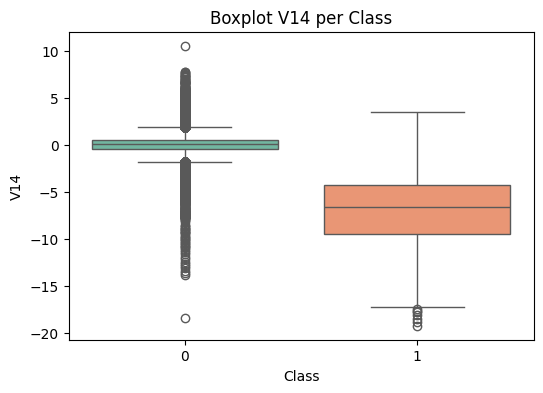

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


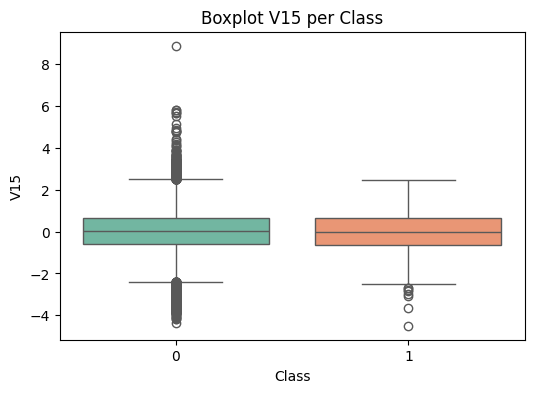

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


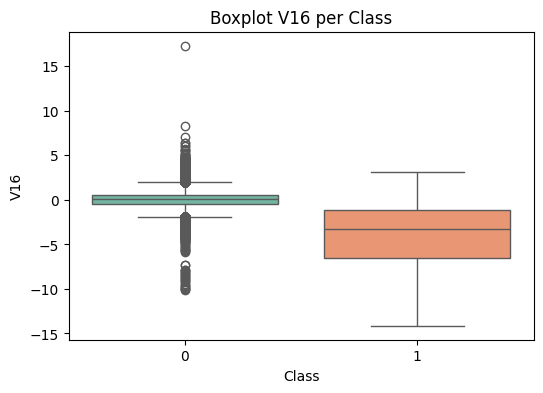

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


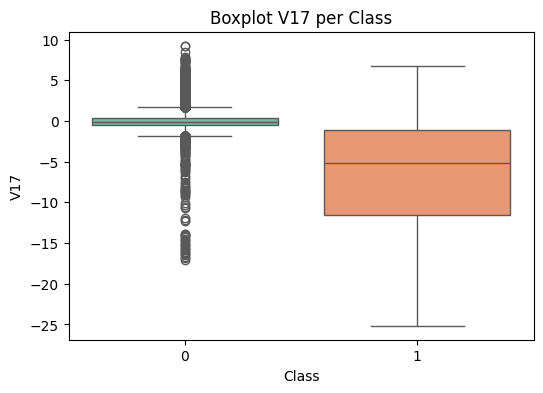

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


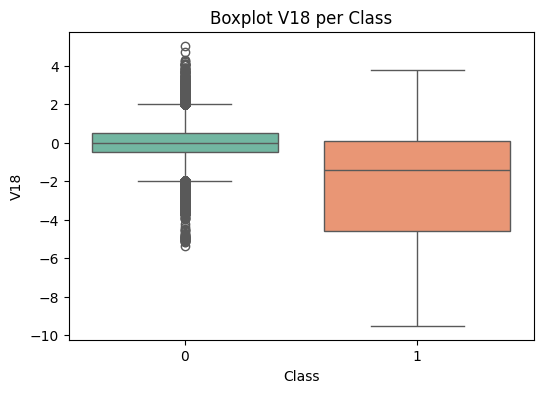

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


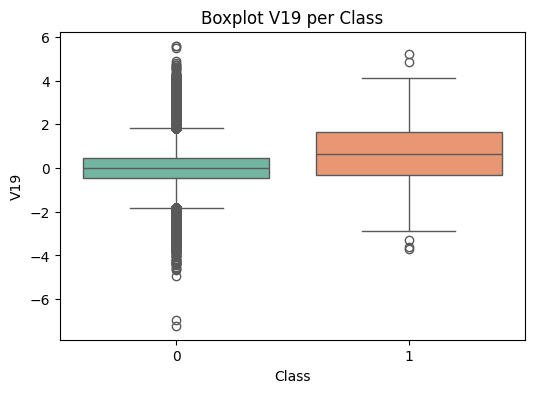

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


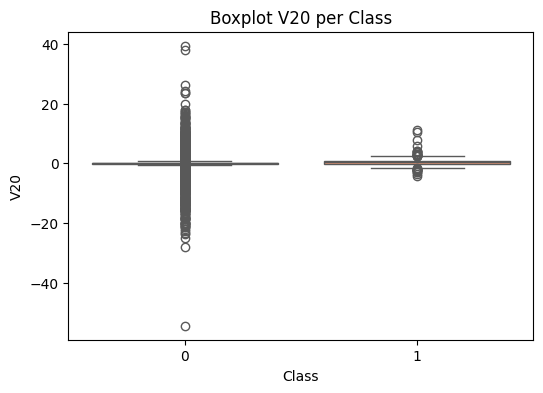

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


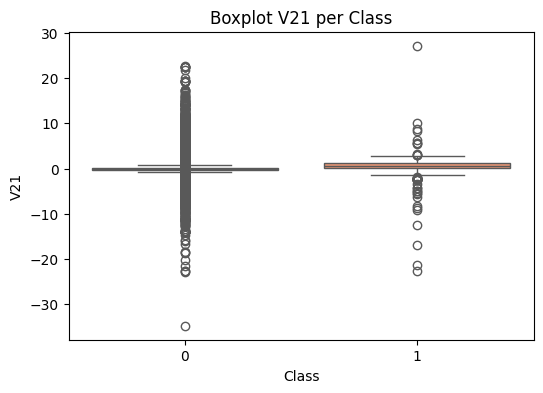

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


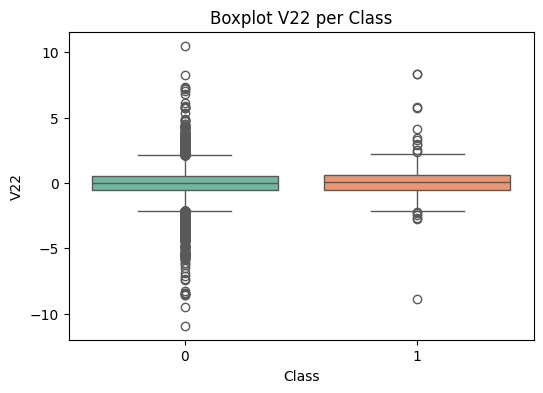

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


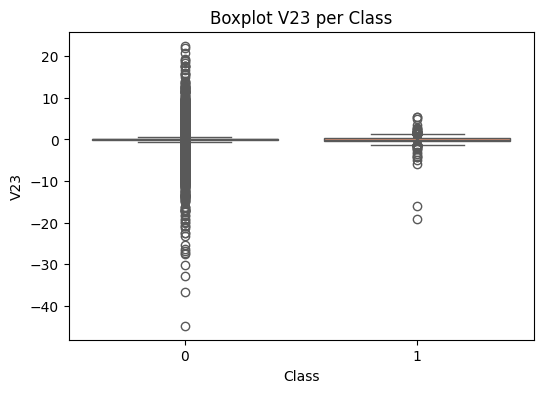

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


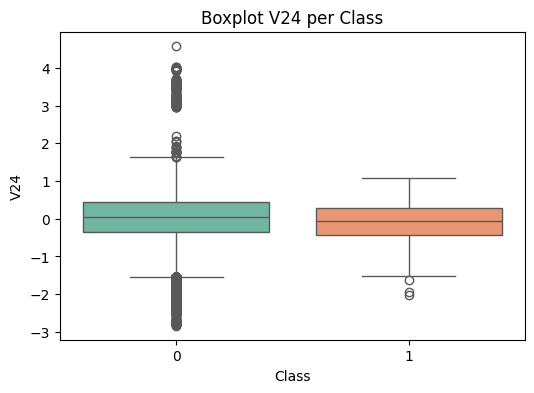

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


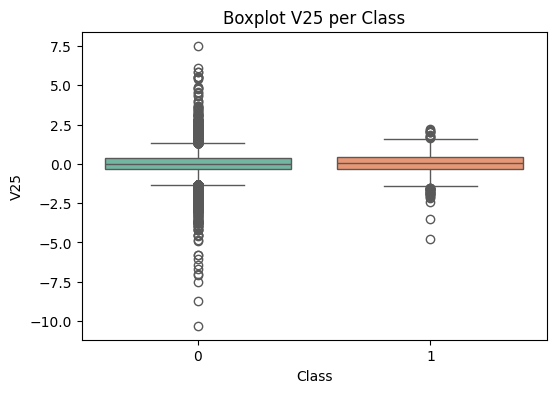

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


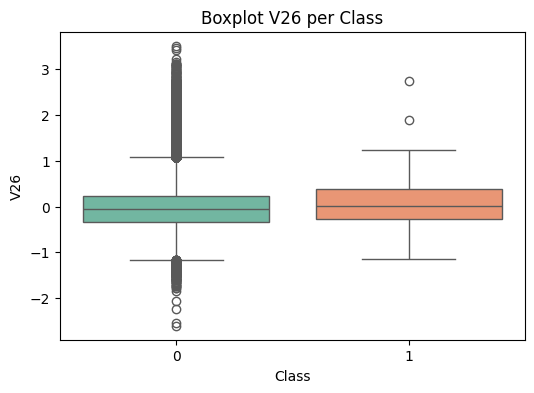

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


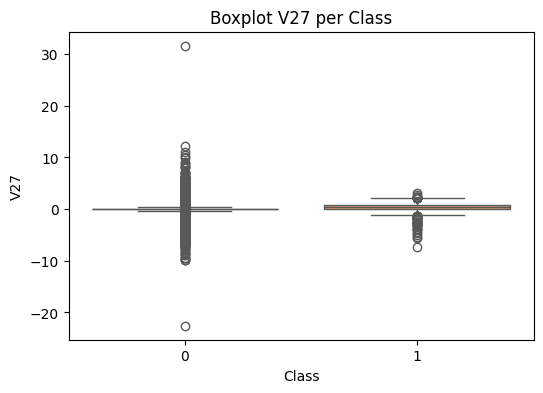

/tmp/ipython-input-2203588401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")


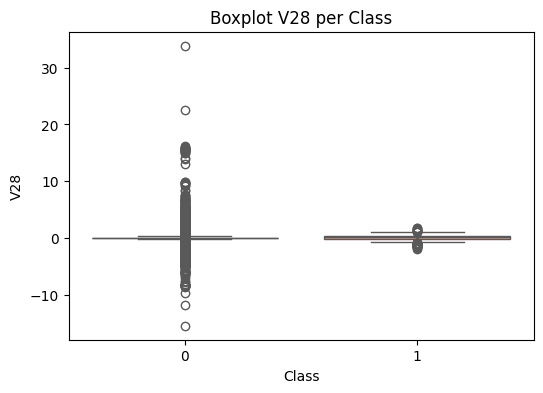

In [16]:
# Cek outlier tiap class per fitur
for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=cu_new, x="Class", y=col, palette="Set2")
    plt.title(f"Boxplot {col} per Class")
    plt.show()

Dari gambar box plot terseubt, terlihat bahwa median dan outlier antara class 0 dan 1 yang berbeda pada fitur V3,V4,V7,V9,V10,V11,V12,V14,V16,17,dan V18 yg memudahkan perbedaan antara fraud dan non-fraud pada fitur tersebut.

## Kesimpulan






1.   Karakteristik nasabah penipuan
    dari matriks korelasi, histogram, dan boxplot. karakteristik penipuan biasanya ada pada fitur V3,4,7,9,10,11,12,14,16,17,18. Artinya, nasabah buruk sering punya pola nilai ekstrim atau median yang berbeda dari normalnya.

2.   Nasabah Baik
    sedangkan pada nasabah baik, kebanyakan distribusi nya lebih stabil dan simetris dan berkumpul di sekitar median

3.   Karakteristik penting
    sehingga, fitur V3,V4,V7,V9,V10,V11,V12,V14,V16,V17,V18 bisa dijadikan dasar bagi algoritma machine learning dalam memprediksi siapa nasabah baik dan siapa yang berisiko fraud.


# Training the model (LogReg)

In [17]:
# pilih fitur yang sudah di eksplorasi sebelumnya
selected_features = ["V3","V4","V7","V9","V10","V11","V12","V14","V16","V17","V18","Amount"]
X = cu_new[selected_features]
y = cu_new["Class"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Normalisasi dahulu
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

# pakai SMOTE karena data imbalance dan logistic regression kurang terhadap data imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_norm, y_train)

In [18]:
y_train_res.value_counts()

,count
Class,
0,198277
1,198277


In [19]:
# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_res, y_train_res)

# Evaluasi dan tuning threshold
y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:,1]
y_pred_custom = (y_pred_proba > 0.2768).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print(classification_report(y_test, y_pred_custom, digits=4))

[[82426  2550]
 [   29   113]]
              precision    recall  f1-score   support

           0     0.9996    0.9700    0.9846     84976
           1     0.0424    0.7958    0.0806       142

    accuracy                         0.9697     85118
   macro avg     0.5210    0.8829    0.5326     85118
weighted avg     0.9981    0.9697    0.9831     85118

              precision    recall  f1-score   support

           0     0.9997    0.9438    0.9710     84976
           1     0.0239    0.8239    0.0465       142

    accuracy                         0.9436     85118
   macro avg     0.5118    0.8839    0.5087     85118
weighted avg     0.9981    0.9436    0.9694     85118



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## Evaluating the model

Pada class 1, saat evaluasi dengan threshold default(0,5), nilai precisonnya 0.0424 sedangkan nilai recallnya 0.7958, ketika thresholdnya diturunkan menjadi (0.16) nilai naik recallnya menjadi 0.9507 dan precisionnya turun menjadi 0.0062, ketika thresholdnya dinaikan menjadi (0.76) nilai recalnya 0.9014 dan precisionnya 0.0253 dan beberapa penyesuain threshold. sehingga dapat disimpulkan bahwa :


*   ketika threshold dinaikkan -> model agresif -> recall naik, precision turun.

*   ketika threshold diturunkan -> model lebih agresif -> recall meningkat drastis, precision turun drastis pula

untuk mendeteksi sebanyak mungkin fraud, saya memungkian merendahkan precision selama recall tetap tinggi. hal ini karena melewatkan fraud (FN) jauh lebih berbahaya dibanding mengira cust penipu padahal tidak (FP). jika recall tinggi,  hampir semua fraud tertangkap, meskipun terdapat beberapa transaksi normal yang “ikut dicurigai”. sehingga, saya melakukan penyesuaian threshold di sekitar nilai default dan mendapat nilai 0.2768 adalah pilihan paling seimbang untuk tujuan mendeteksi fraud



# Training the model (RF)

Pada model ini, saya tidak lagi menggunakan SMOTE untuk menyeimbangkan data imbalance dikarenakan saya menggunakan Bayesian Optimatization sebagai Hyperparameter tuning. sehingga ketika membuat SMOTE, membuat dataset semakin banyak dan memakan banyak memori
. Oleh karena itu, saya menggunakan class_weight sebagai gantinya. dan masih tetap fokus dengan tujuan menaikkan nilai recall.

In [20]:
# Melakukan tuning hyperparameter agar mendapat hasil model yang baik
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300), # jumlah pohon
        "max_depth": trial.suggest_categorical("max_depth", [None, 5, 10, 20]), # kedalaman pohon
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10), # minimal sample untuk split
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),      # minimal sample per daun
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]), # jumlah fitur yang dipakai di setiap split
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),  # sampling dengan/ tanpa replacement
        "class_weight": "balanced",                                           # atasi imbalance langsung
        "n_jobs": -1,
        "random_state": 42
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = RandomForestClassifier(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        f1 = f1_score(y_val, y_pred, pos_label=1) # fokus ke kelas yg dianggap positif(kelas 1)
        f1_scores.append(f1)

    return np.mean(f1_scores)

In [21]:
study = optuna.create_study(direction="maximize") # optuna akan mencari nilai objective(f1_scores) yang terbesar
study.optimize(objective, n_trials=30)  # menjalankan pencarian sebanyak 30 percobaan

[I 2026-01-18 08:39:23,476] A new study created in memory with name: no-name-05e74303-5d29-4d72-a38d-c4ecfe7e279a
[I 2026-01-18 08:45:11,795] Trial 0 finished with value: 0.8376664537359659 and parameters: {'n_estimators': 141, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.8376664537359659.
[I 2026-01-18 09:22:29,257] Trial 1 finished with value: 0.8337549730133549 and parameters: {'n_estimators': 283, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.8376664537359659.
[I 2026-01-18 09:41:04,582] Trial 2 finished with value: 0.8067582100791885 and parameters: {'n_estimators': 280, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.8376664537359659.
[I 2026-01-18 10:25:34,094] Trial 3 finished with value: 0.3884620055964147 a

In [22]:
#  Membuat model Random Forest dengan parameter terbaik yang didapat
best_model = RandomForestClassifier(
    **study.best_params, # ubah jadi keyword arguments(isi dict jadi param)

    # parameter dibawah tetap ditulis karena Optuna tidak otomatis menyimpan parameter Fixed
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

# Melatih model dengan data training
best_model.fit(X_train, y_train)


RandomForestClassifier(bootstrap=False, class_weight='balanced',
                       max_features='log2', min_samples_leaf=2,
                       min_samples_split=4, n_estimators=190, n_jobs=-1,
                       random_state=42)

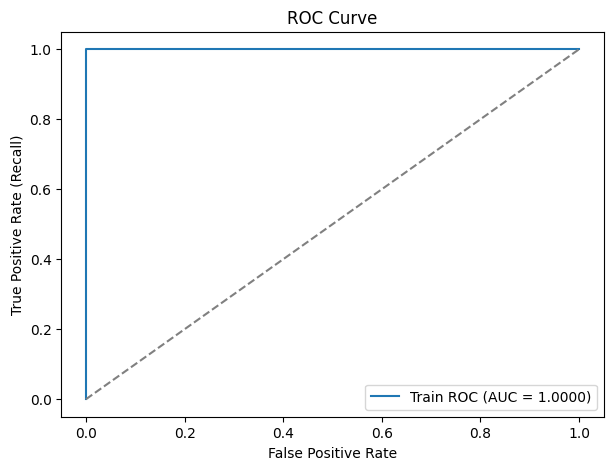

In [23]:
# Prediksi probabilitas pada setiap data di X yang termasuk ke dalam kelas 1 (positif)
proba_train = best_model.predict_proba(X_train)[:,1]
proba_test  = best_model.predict_proba(X_test)[:,1]

# ROC curve untuk melihat threshold yang paling cocok untuk model dapat belajar
fpr_tr, tpr_tr, thresholds_tr = roc_curve(y_train, proba_train)
roc_auc_tr = auc(fpr_tr, tpr_tr)

plt.figure(figsize=(7,5))
plt.plot(fpr_tr, tpr_tr, label=f'Train ROC (AUC = {roc_auc_tr:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

Hasil ROC curve  ini menunjukkan nilai AUC sebesar 1.0000 atau nilai sempurna, yang berarti model Random Forest dengan class_weight balanced dan Bayesian memiliki kemampuan sangat baik dalam membedakan transaksi fraud dan non-fraud. Selain itu, Random forest memang model kompleks yang gampang mempelajari pola detail sehingga hasilnya sangat baik. untuk lebih jelasnya, saya membandingkannya dengan roc curve di test dan melihat nilai f1 di best param dengan di test.

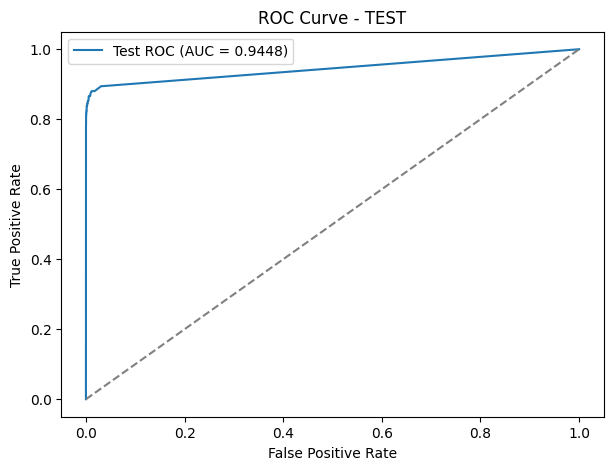

In [24]:
fpr_te, tpr_te, _ = roc_curve(y_test, proba_test)
roc_auc_te = auc(fpr_te, tpr_te)

plt.figure(figsize=(7,5))
plt.plot(fpr_te, tpr_te, label=f'Test ROC (AUC = {roc_auc_te:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - TEST')
plt.legend()
plt.show()


Dari gambar, dapat kita lihat bahwa hasil evaluasi ROC pada data test menunjukkan AUC Test = 0.94. Seperti yang kita ketahui semakin tinggi nilai AUC (mendekati 1), semakin baik performa klasifikasi model. Nilai ini menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam membedakan antara kelas positif dan negatif. meskipun kurva ROC pada data test tidak membentuk sudut siku sempurna seperti pada data training, ini menandakan bahwa model tidak mengalami data leakage dan masih mampu melakukan generalisasi.

In [26]:
# Membuat threshold pada train dan test pada ambang batas general
y_train_pred = (proba_train >= 0.5).astype(int)
y_test_pred  = (proba_test  >= 0.5).astype(int)

In [27]:
# melihat classification report di data train dan test
print("=== TRAIN ===")
print(classification_report(y_train, y_train_pred, digits=4))

print("=== TEST ===")
print(classification_report(y_test, y_test_pred, digits=4))

=== TRAIN ===
              precision    recall  f1-score   support

           0     1.0000    0.9999    1.0000    198277
           1     0.9678    1.0000    0.9837       331

    accuracy                         0.9999    198608
   macro avg     0.9839    1.0000    0.9918    198608
weighted avg     0.9999    0.9999    0.9999    198608

=== TEST ===
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     84976
           1     0.9469    0.7535    0.8392       142

    accuracy                         0.9995     85118
   macro avg     0.9732    0.8767    0.9195     85118
weighted avg     0.9995    0.9995    0.9995     85118



In [25]:
# melihat nilai rata-rata f1-score terbaik yang diambil dari Bayesian Optimitization
study.best_value

0.8655220758598763

## Evaluating the model


Berdasarkan hasil evaluasi, terdapat perbedaan performa antara data training dan data test yang menurut saya masih berada dalam batas wajar, dengan nilai F1-score kelas positif pada data training sebesar sekitar 0.98 dan pada data test sebesar sekitar 0.83. Perbedaan ini menunjukkan bahwa model tidak mengalami overfitting secara signifikan dan masih mampu melakukan generalisasi dengan baik pada data baru. Selain itu, hasil Bayesian Optimization menghasilkan nilai rata-rata F1-score cross-validation sebesar 0.86(meskipun masih lebih tinggi dari data test), yang mencerminkan kestabilan performa model selama proses tuning hyperparameter. Hal ini membuktikan bahwa penggunaan threshold default sebesar 0.5 tidak selalu optimal.

Sebagai perbandingan, model LogReg sebelumnya, menghasilkan recall tinggi yang membuat hampir semua fraud berhasil ditangkap, tetapi konsekuensinya akan menerima banyak sekali false alarm yang tidak efisien dari sisi operasional. setelah saya pertimbangkan kembali, meskipun persentase recall sangat penting untuk deteksi fraud, akan sangat efisien jika recall dan precision memiliki persentase yang seimbang.

Dengan demikian, Model Random Forest cocok untuk penggunaan dalam operasional sehari-hari karena mampu menyeimbangkan antara efektivitas deteksi fraud dan efisiensi penanganan penipuan.